In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

# number of data
N=5000
# size of each sample
L=4
# box size
B=100

!mkdir DATA

mkdir: cannot create directory ‘DATA’: File exists


2 5 1
DATA/x_XGB_26.dat
DATA/y_XGB_26.dat


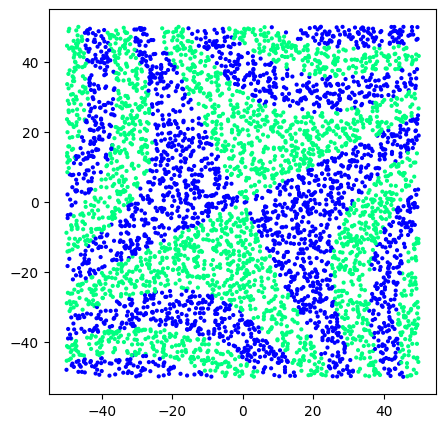

In [3]:
def f(x):
    Q=np.heaviside(np.sin(np.pi*(x[1]+2*x[0])*(2*x[1]-x[0])/2000),0)
    return Q

def filename(s):
    return "DATA/"+s+".dat"

# random seed for reproducibility
np.random.seed(12345)
print(np.random.randint(0,10),np.random.randint(0,10),np.random.randint(0,10))

x,y = (np.random.random((N,L))-0.5)*B, np.zeros(N).astype(int)
for i in range(N):
    # label data according to a nonlinear function "f" using only the first two features
    y[i] = f(x[i,:2])

plt.figure(figsize = (5,5))
plt.scatter(x[:,0],x[:,1],c=y,s=4,cmap="winter")
plt.show

fn=filename("x_XGB_26")
print(fn)

np.savetxt(fn,x,fmt="%.3f")
fn=filename("y_XGB_26")
np.savetxt(fn,y,fmt="%d")
print(fn)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
# AdaBoost Algorithm
from sklearn.ensemble import AdaBoostClassifier
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
# XGBoost
import xgboost
from xgboost import XGBClassifier
from xgboost import plot_importance, to_graphviz, plot_tree
print("XGBoost version:",xgboost.__version__)

mycmap = "winter"
mpl.rcParams['image.cmap'] = mycmap
plt.rcParams['font.size'] = 13

XGBoost version: 3.2.0


In [2]:
# np.random.seed(12345)

dname="./DATA/"
str0="_XGB_26.dat"
fnamex=dname+'x'+str0
fnamey=dname+'y'+str0
x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y = np.loadtxt(fnamey)
y = y.astype(int)
N,L = len(x), len(x[0])

N_train = int(0.75*N)
x_train,y_train = x[:N_train],y[:N_train]
x_test,y_test = x[N_train:],y[N_train:]
print(f"N={N}, N_train={N_train}, L={L}")

N=5000, N_train=3750, L=4


[-31.608 -29.544   6.773   9.554] 0
[46.451 15.318 24.891 15.357] 0
[ 24.771  46.131 -49.161 -39.356] 0
[-20.13   15.641  30.981  37.218] 0
[46.465 22.369 14.248 21.745] 0


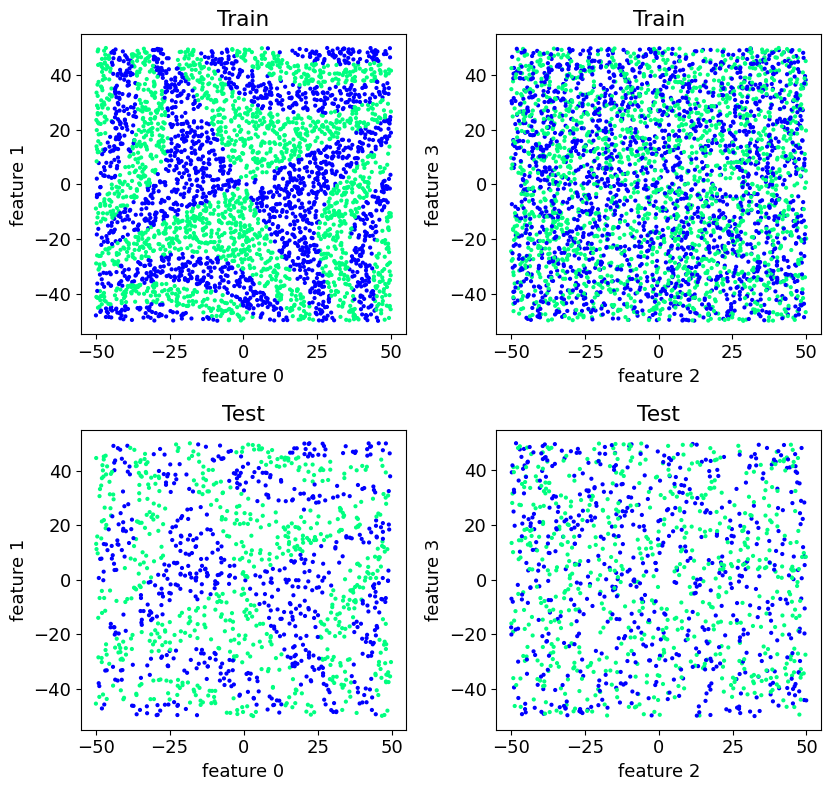

In [5]:
def scat(ax,x,y,i=0,j=1,s=4,title=""):
    # scatter plot of the data in the plane of features i and j
    ax.scatter(x[:,i],x[:,j],s=s,c=y)
    ax.set_xlabel(f"feature {i}")
    ax.set_ylabel(f"feature {j}")
    ax.set_title(title)

# print the first 5 data points
for n in range(5):
    print(x[n],y[n])

#print feature plots for the training and test sets
fig,AX = plt.subplots(2,2,figsize=(8.5,8.1))
scat(AX[0,0],x_train,y_train,title="Train")
scat(AX[0,1],x_train,y_train,i=2,j=3,title="Train")
scat(AX[1,0],x_test,y_test,title="Test")
scat(AX[1,1],x_test,y_test,i=2,j=3,title="Test")
fig.tight_layout()
plt.show()

In [7]:
def classify(clf=GradientBoostingClassifier(),show=False):
    clf.fit(x_train,y_train) # train the model on the training set
    return clf.score(x_test, y_test)

In [18]:
from tqdm import tqdm # Optional: Install with 'pip install tqdm'
import numpy as np
import xgboost as xgb
from tqdm import tqdm

N_e = np.arange(70,120,5)
depth = np.arange(4,24,2)
Lambdas = np.linspace(1,5,10)
Gamma = np.linspace(0.5,2,10)




# Updated dimensions: (n_estimators, max_depth, lambda, gamma)
results = np.zeros((10, 10, 10, 10))

for i in tqdm(range(10), desc="Computing Grid"):
    for j in range(10):
        for l in range(10):
            for m in range(10):

                model = xgb.XGBClassifier(
                    n_estimators=N_e[i],
                    max_depth=depth[j],
                    learning_rate=0.1,
                    reg_lambda=Lambdas[l],
                    gamma=Gamma[m],
                    eval_metric='logloss',
                    n_jobs=-1            # Use all CPU cores
                )


                results[i, j, l, m] = classify(model)

np.save('xgb_4d_results.npy', results)

Computing Grid: 100%|██████████| 10/10 [23:18<00:00, 139.84s/it]


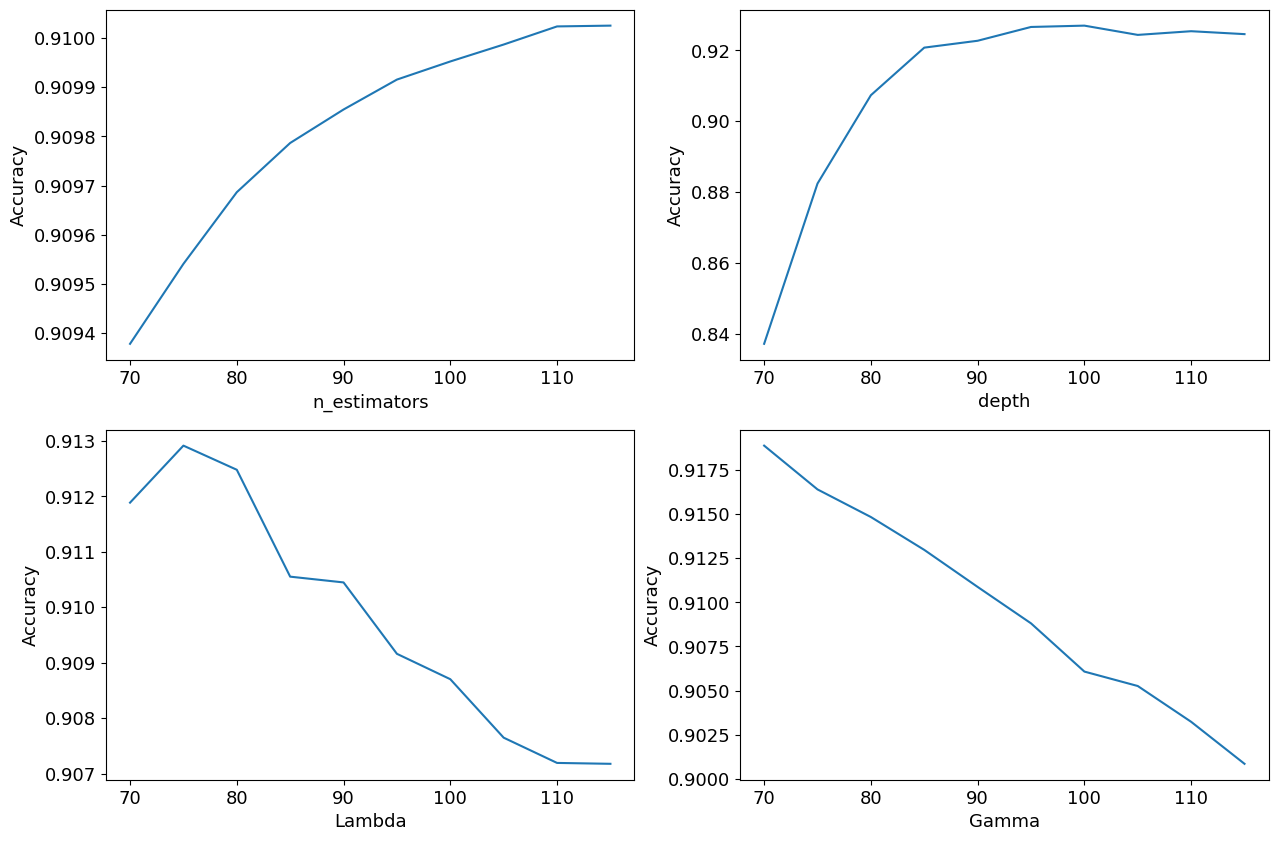

In [25]:
plt.figure(figsize=(15, 10))

plt.subplot(221)
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.plot(N_e,np.mean(results, axis=(1, 2, 3)))

plt.subplot(222)
plt.xlabel("depth")
plt.ylabel("Accuracy")
plt.plot(N_e,np.mean(results, axis=(0, 2, 3)))

plt.subplot(223)
plt.xlabel("Lambda")
plt.ylabel("Accuracy")
plt.plot(N_e,np.mean(results, axis=(0, 1, 3)))

plt.subplot(224)
plt.xlabel("Gamma")
plt.ylabel("Accuracy")
plt.plot(N_e,np.mean(results, axis=(0, 1, 2)))